In [5]:
import pandas as pd
from ast import literal_eval

expr = '22months'

nc_df = pd.read_table(
    f'../results/mouse_muscle/{expr}/IRE1_KO_vs_WT.non_canonical_junctions.filtered.tsv',
    converters={'original_exons': literal_eval, 'new_exons': literal_eval, 'spliced_exons': literal_eval}
)

nc_df = nc_df[nc_df['spliced_exons'].apply(len) != 0].copy()
nc_df['spliced_sizes'] = nc_df['spliced_exons'].apply(lambda x: sum([end - start for start, end in x]))

nc_df.drop_duplicates(['chr', 'start', 'end', 'genes'], inplace=True)

nc_df['genes'].to_csv(f'../results/mouse_muscle/{expr}/spliced_genes.txt', header=None, index=False)

nc_df = nc_df.groupby(
    ['chr', 'start', 'end', 'WT_uniq', 'WT_multi', 'IRE1_KO_uniq', 'IRE1_KO_multi', 'WT_uniq.count']
).agg({ 'genes': lambda x: '/'.join(x.tolist()) , 'spliced_sizes': 'min' }).reset_index()

nc_df.sort_values(by='WT_uniq.count', inplace=True, ascending=False)
nc_df

,chr,start,end,WT_uniq,WT_multi,IRE1_KO_uniq,IRE1_KO_multi,WT_uniq.count,genes,spliced_sizes
4,chr11,5474277,5474303,"7,13,12,2","1,0,0,2","1,0,0,0","0,0,0,0",34,Xbp1,26
2,chr1,173160420,173160431,"2,2,6,1","0,0,0,0","0,0,0,0","0,0,0,0",11,Ackr1,11
31,chr8,96598587,96598884,"7,1,0,0","0,0,0,0","0,1,0,0","0,0,0,0",8,Got2,117
26,chr7,30822449,30822482,"3,0,0,4","0,0,0,0","0,0,0,1","0,0,0,0",7,Scn1b,33
20,chr4,148709626,148709717,"4,1,0,2","0,0,0,0","1,0,0,0","0,0,0,0",7,Tardbp,91
8,chr13,108189188,108189220,"0,2,5,0","0,0,0,0","0,0,0,0","0,0,0,0",7,Ndufaf2,32
9,chr15,76901840,76901907,"4,1,0,2","0,0,0,0","0,0,0,0","0,0,0,0",7,Mb,67
17,chr3,67291967,67301311,"3,1,3,0","0,0,0,0","1,0,0,0","0,0,0,0",7,Mlf1,192
15,chr17,87136504,87138401,"1,2,3,1","0,0,0,0","0,0,1,0","0,0,0,0",7,Epas1,221
7,chr11,73067456,73067534,"4,0,1,2","0,0,0,0","0,0,0,1","0,0,0,0",7,Emc6,78


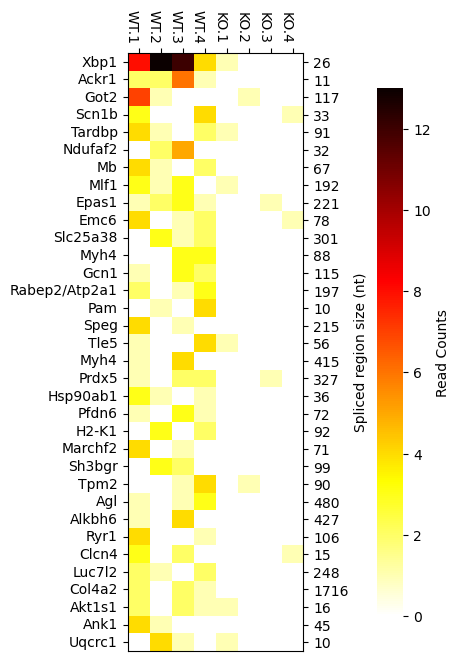

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

samples = ['WT.1', 'WT.2', 'WT.3', 'WT.4', 'KO.1', 'KO.2', 'KO.3', 'KO.4']
genes = []
spliced_sizes = []
data = []
for i, row in nc_df.iterrows():
    genes.append(row['genes'])
    spliced_sizes.append(str(row['spliced_sizes']))
    wt_uniq = [int(i) for i in row['WT_uniq'].split(',')]
    wt_multi= [int(i) for i in row['WT_multi'].split(',')]
    ko_uniq = [int(i) for i in row['IRE1_KO_uniq'].split(',')]
    ko_multi = [int(i) for i in row['IRE1_KO_multi'].split(',')]

    wt_total = [a+b for a, b in zip(wt_uniq, wt_multi)]
    ko_total = [a+b for a, b in zip(ko_uniq, ko_multi)]

    data.append(wt_total + ko_total)


fig, ax = plt.subplots(layout='constrained', figsize=(4.5, 6.5), dpi=100)
sns.heatmap(data, ax=ax, cmap='hot_r', cbar_kws={'label': 'Read Counts'}, yticklabels=genes, xticklabels=samples)

ax.set_xticklabels(ax.get_xticklabels(), rotation=-90, ha='right')
ax.tick_params(top=True, bottom=False, labeltop=True, labelbottom=False)

bx = ax.twinx()
bx.set_ylim(ax.get_ylim())
bx.set_yticks(ax.get_yticks())
bx.set_yticklabels(spliced_sizes)
bx.set_ylabel('Spliced region size (nt)')

plt.show()

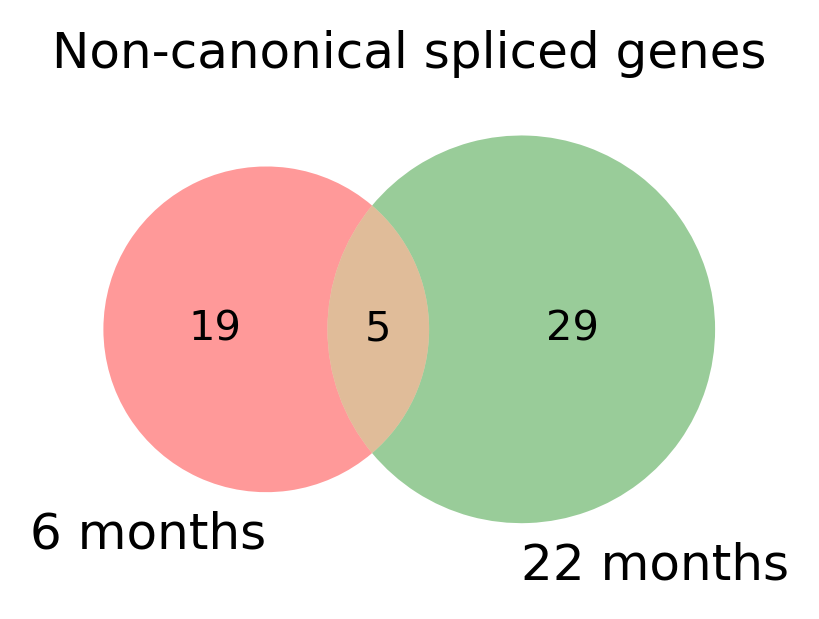

{'Atp2a1', 'Prdx5', 'Agl', 'Mlf1', 'Xbp1'}


In [7]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

genes_6m = set()
genes_22m = set()
with open('../results/mouse_muscle/6months/spliced_genes.txt') as gene_6m_f:
    for line in gene_6m_f:
        genes_6m.add(line.strip())

with open('../results/mouse_muscle/22months/spliced_genes.txt') as gene_22m_f:
    for line in gene_22m_f:
        genes_22m.add(line.strip())

plt.figure(figsize=(3, 3), dpi=300)
g = venn2(subsets=(genes_6m, genes_22m), set_labels=('6 months', '22 months'))
plt.title("Non-canonical spliced genes")
plt.show()

print(genes_6m & genes_22m)